# Part 2: RNN

### Upload the dataset for creation of RNN, and check characteristics

In [3]:
!pip install -U keras-tuner


  Using cached keras_tuner-1.4.7-py3-none-any.whl.metadata (5.4 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.7-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
import pandas as pd
import numpy as np

# Cyclic encoding helper
def cyclic_encode(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# Load dataset
file_path = "/Users/filiporlikowski/Documents/enProject/training_of_price_predictive_model/"
df = pd.read_csv(f"{file_path}/merged_dataset.csv")

# If 'date' column exists, extract month
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['month'] = df['date'].dt.month
    df = cyclic_encode(df, 'month', 12)
else:
    print("❗ Column 'date' not found in dataset.")

# Optional: Save or inspect
# df.to_csv("with_cyclic_encoding.csv", index=False)
print(df[['month', 'month_sin', 'month_cos']].head())


   month     month_sin  month_cos
0      6  1.224647e-16       -1.0
1      6  1.224647e-16       -1.0
2      6  1.224647e-16       -1.0
3      6  1.224647e-16       -1.0
4      6  1.224647e-16       -1.0


Now we have understood the basic characterstics of the dataset, and we know the following metadata:

**Data Fields**

- datetime - hourly date + timestamp  
- season -  1 = spring, 2 = summer, 3 = fall, 4 = winter
- holiday - whether the day is considered a holiday
- workingday - whether the day is neither a weekend nor holiday
- weather -
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp - temperature in Celsius
- atemp - "feels like" temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- casual - number of non-registered user rentals initiated
- registered - number of registered user rentals initiated
- count - number of total rentals

### Exploratory Data Analysis

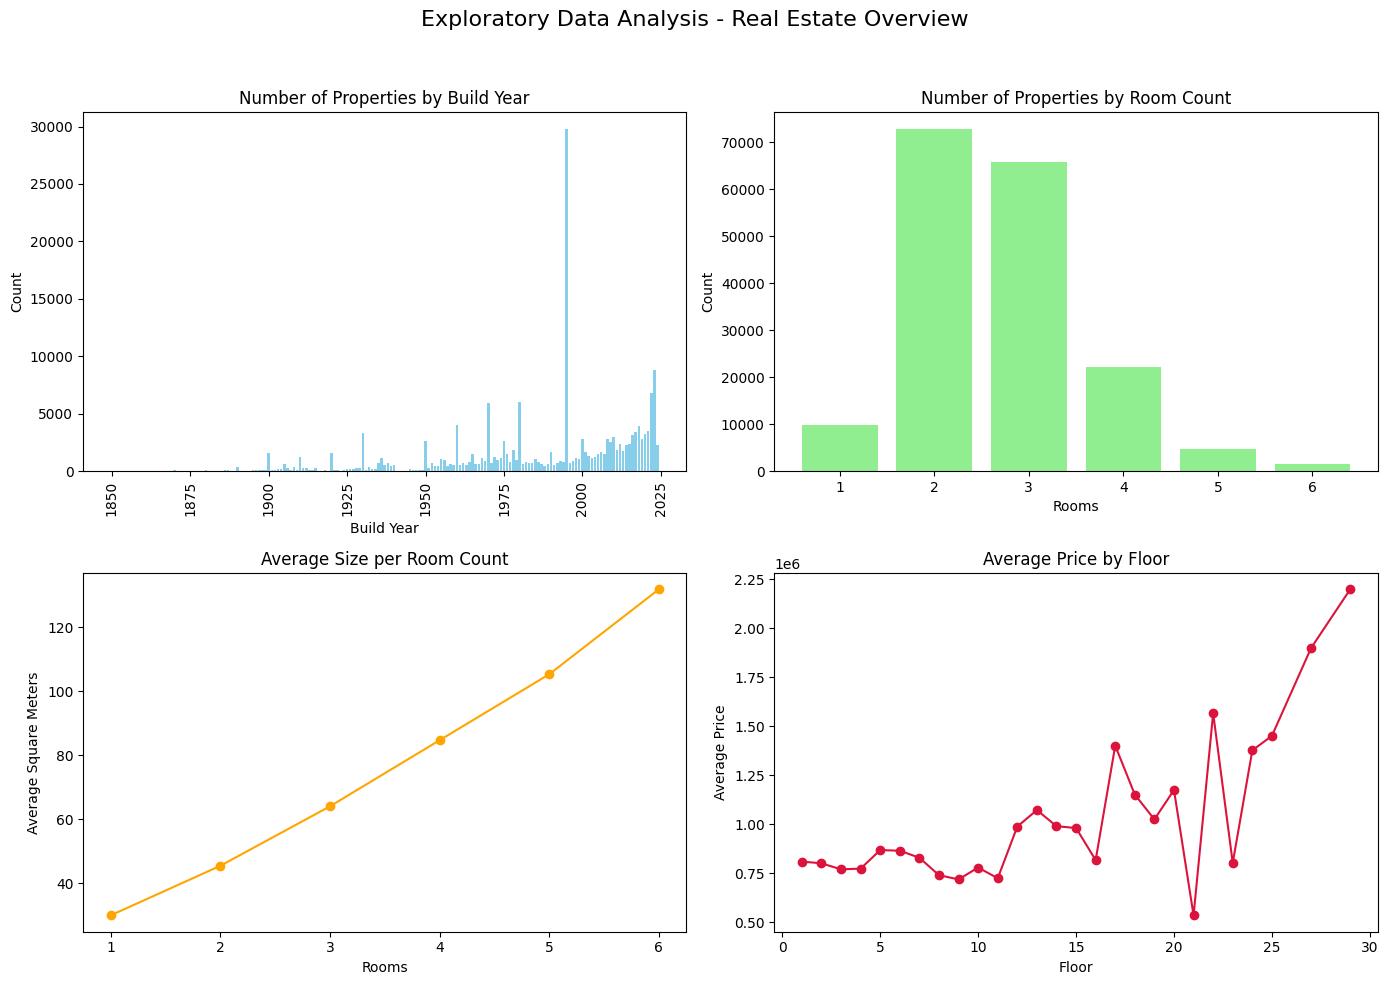

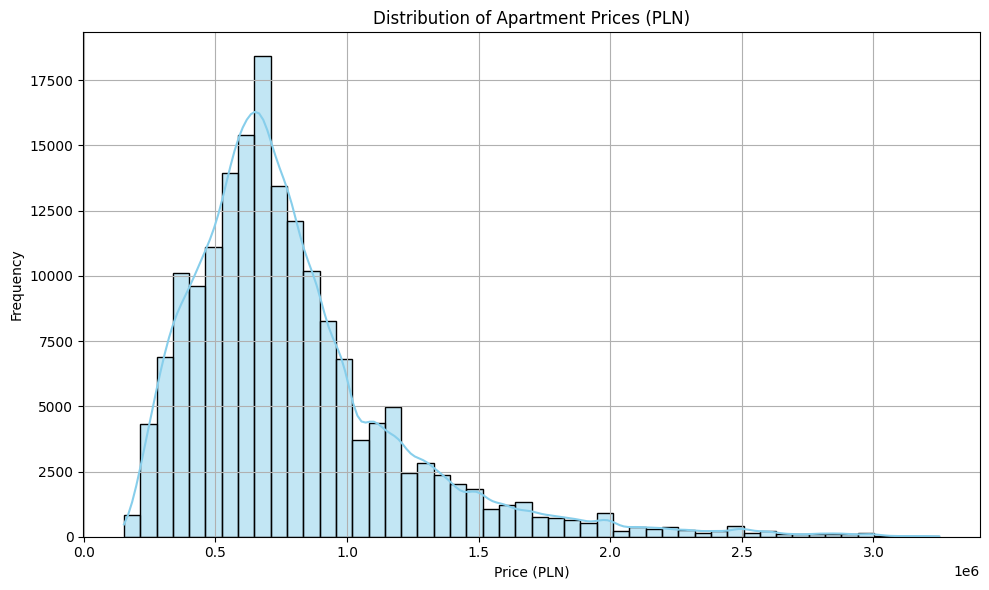

Summary Statistics:
count    1.766630e+05
mean     7.939881e+05
std      4.148964e+05
min      1.526200e+05
25%      5.297000e+05
50%      6.990000e+05
75%      9.450000e+05
max      3.250000e+06
Name: price, dtype: float64

Price Distribution Table:
  Price Range (PLN)  Count
0             <200k    569
1         200k–400k  21636
2         400k–600k  40866
3         600k–800k  49212
4           800k–1M  28852
5           1M–1.5M  24859
6           1.5M–2M   7184
7               >2M   3485


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Carreguem les dades
# Assume 'df' is your DataFrame (e.g., df = pd.read_csv('yourfile.csv'))

# Elimina registres amb valors nuls essencials per aquesta anàlisi
df = df.dropna(subset=['buildYear', 'floor', 'rooms', 'price', 'squareMeters'])

# Prepara la figura
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis - Real Estate Overview", fontsize=16)

# Distribució d'habitatges per any de construcció
build_year_counts = df['buildYear'].astype(int).value_counts().sort_index()
axs[0, 0].bar(build_year_counts.index, build_year_counts.values, color='skyblue')
axs[0, 0].set_title("Number of Properties by Build Year")
axs[0, 0].set_xlabel("Build Year")
axs[0, 0].set_ylabel("Count")
axs[0, 0].tick_params(axis='x', labelrotation=90)

# Distribució per nombre d'habitacions
room_counts = df['rooms'].value_counts().sort_index()
axs[0, 1].bar(room_counts.index, room_counts.values, color='lightgreen')
axs[0, 1].set_title("Number of Properties by Room Count")
axs[0, 1].set_xlabel("Rooms")
axs[0, 1].set_ylabel("Count")

# Superfície mitjana per nombre d'habitacions
avg_sq_per_room = df.groupby('rooms')['squareMeters'].mean()
axs[1, 0].plot(avg_sq_per_room.index, avg_sq_per_room.values, marker='o', color='orange')
axs[1, 0].set_title("Average Size per Room Count")
axs[1, 0].set_xlabel("Rooms")
axs[1, 0].set_ylabel("Average Square Meters")

# Preu mitjà per planta (floor)
avg_price_per_floor = df.groupby('floor')['price'].mean()
axs[1, 1].plot(avg_price_per_floor.index, avg_price_per_floor.values, marker='o', color='crimson')
axs[1, 1].set_title("Average Price by Floor")
axs[1, 1].set_xlabel("Floor")
axs[1, 1].set_ylabel("Average Price")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Apartment Prices (PLN)')
plt.xlabel('Price (PLN)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

summary_stats = df['price'].describe()
print("Summary Statistics:")
print(summary_stats)

# Distribution bins (you can adjust bin edges as needed)
bin_edges = [0, 200000, 400000, 600000, 800000, 1000000, 1500000, 2000000, df['price'].max()]
bin_labels = ['<200k', '200k–400k', '400k–600k', '600k–800k', '800k–1M', '1M–1.5M', '1.5M–2M', '>2M']

# Cut into bins
df['price_bin'] = pd.cut(df['price'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# Frequency table
price_dist_table = df['price_bin'].value_counts().sort_index()
price_dist_table = price_dist_table.reset_index()
price_dist_table.columns = ['Price Range (PLN)', 'Count']

print("\nPrice Distribution Table:")
print(price_dist_table)


/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


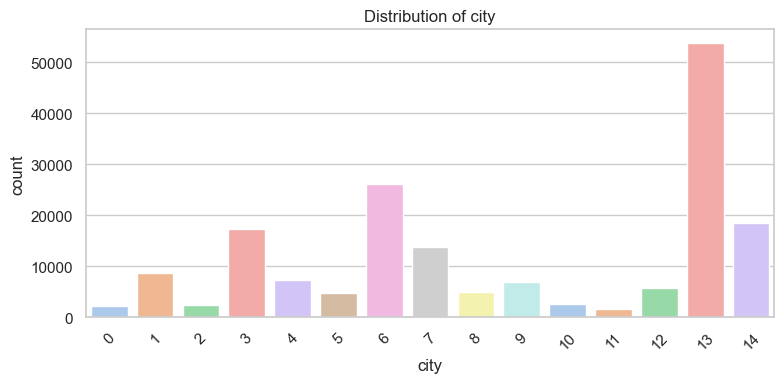

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


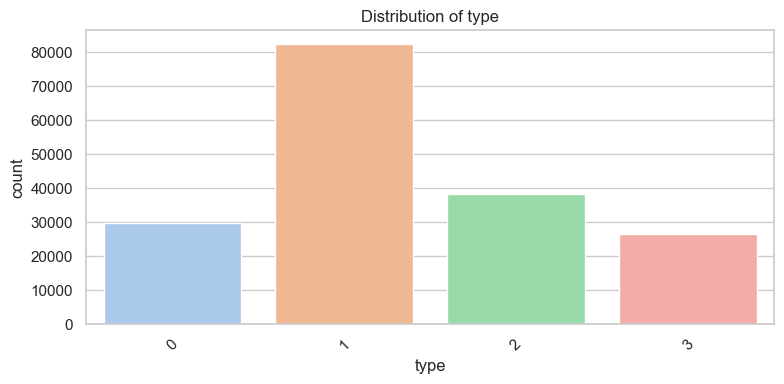

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


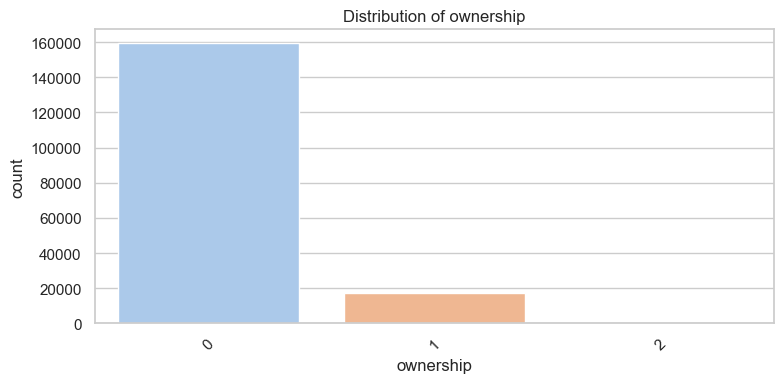

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


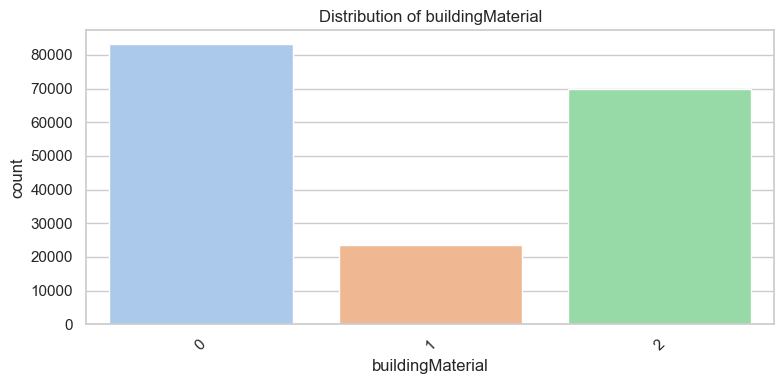

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


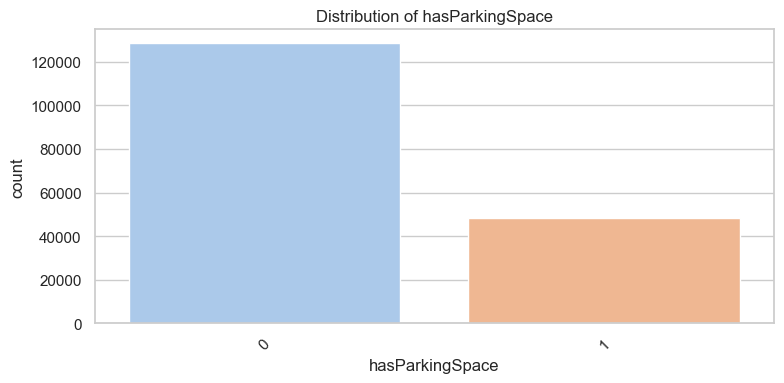

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


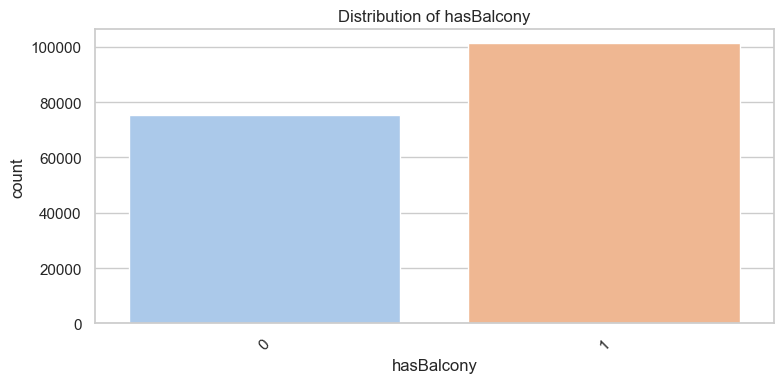

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


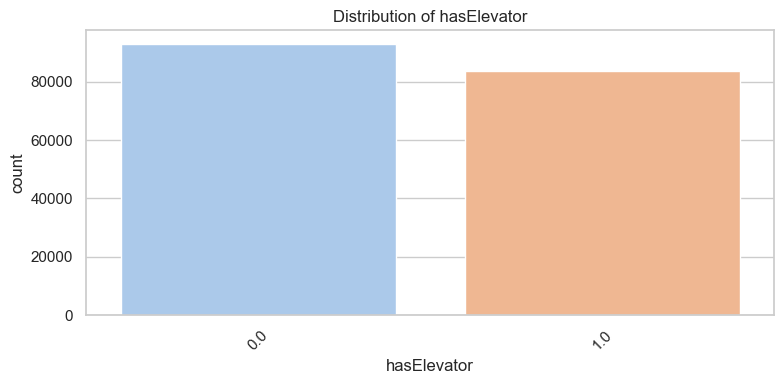

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


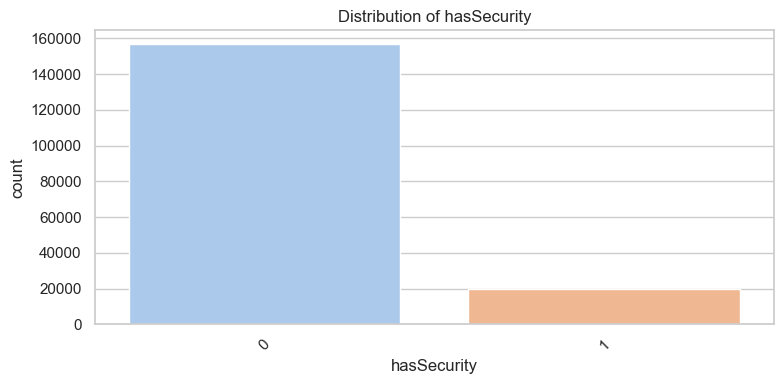

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


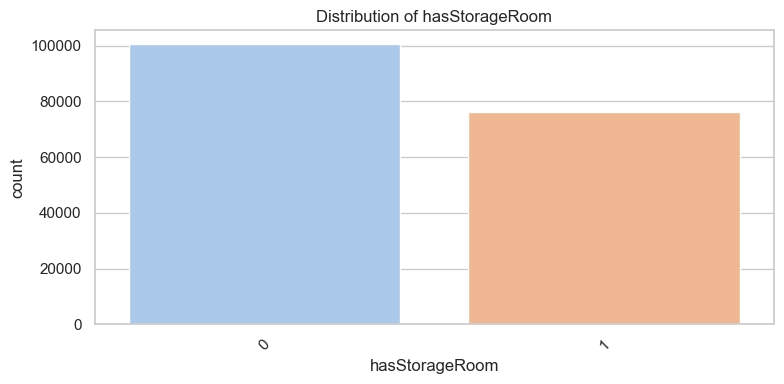

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


categorical_vars = [
    'city', 'type', 'ownership', 'buildingMaterial',
    'hasParkingSpace', 'hasBalcony', 'hasElevator',
    'hasSecurity', 'hasStorageRoom'
]

# Set plot style
sns.set(style="whitegrid")

# Plot each categorical variable
for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=var, palette="pastel")
    plt.title(f'Distribution of {var}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Data Preprocessing

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset


# Define target variable
y = df['price']

# Define features - drop 'price', 'id', and 'date' columns (assuming 'id' and 'date' are not predictive features)
X = df.drop(columns=['price', 'id', 'date'])

# Split into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you have:
# X_train, y_train for training your model
# X_test, y_test for evaluation


In [70]:
print(X_train.columns)
print(X_train.shape)

Index(['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'hasParkingSpace',
       'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom',
       'distance_to_green_spaces_1', 'score_of_green_spaces_1',
       'distance_to_green_spaces_2', 'score_of_green_spaces_2',
       'distance_to_green_spaces_3', 'score_of_green_spaces_3',
       'distance_to_shopping_centers_1', 'distance_to_shopping_centers_2',
       'distance_to_shopping_centers_3', 'distance_to_utilities_1',
       'distance_to_utilities_2', 'distance_to_utilities_3',
       'distance_to_train_stops_1', 'distance_to_train_stops_2',
       'distance_to_train_stops_3', 'distance_to_primary_schools_1',
       'distance_to_primary_schools_2',

### **Useful Libraries and functions and a first model**

In [5]:
import sys
print(sys.executable)
print(sys.version)
#!pip install tensorflow

#import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
import keras_tuner as kt

import sys
print(sys.executable)
print(sys.version)
#!pip install xgboost
import xgboost as xgb
print(xgb.__version__)

/Users/filiporlikowski/Documents/enProject/.venv-tf/bin/python
3.10.12 (main, Apr  2 2025, 09:22:51) [Clang 15.0.0 (clang-1500.1.0.2.5)]
/Users/filiporlikowski/Documents/enProject/.venv-tf/bin/python
3.10.12 (main, Apr  2 2025, 09:22:51) [Clang 15.0.0 (clang-1500.1.0.2.5)]
3.0.2


In [15]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=1,
    colsample_bytree=1,
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=True)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

[0]	validation_0-rmse:400047.24341
[1]	validation_0-rmse:384002.56946
[2]	validation_0-rmse:368869.45246
[3]	validation_0-rmse:354611.90974
[4]	validation_0-rmse:341226.00379
[5]	validation_0-rmse:328367.69488
[6]	validation_0-rmse:316461.36917
[7]	validation_0-rmse:305247.59122
[8]	validation_0-rmse:294468.53463
[9]	validation_0-rmse:284544.55919
[10]	validation_0-rmse:274962.28661
[11]	validation_0-rmse:265927.23557
[12]	validation_0-rmse:257202.68704
[13]	validation_0-rmse:249333.65041
[14]	validation_0-rmse:241610.94192
[15]	validation_0-rmse:234485.36530
[16]	validation_0-rmse:227978.72953
[17]	validation_0-rmse:221452.16585
[18]	validation_0-rmse:215320.37819
[19]	validation_0-rmse:209830.15342
[20]	validation_0-rmse:204499.81382
[21]	validation_0-rmse:199679.35747
[22]	validation_0-rmse:194916.74329
[23]	validation_0-rmse:190401.09197
[24]	validation_0-rmse:186365.19226
[25]	validation_0-rmse:182439.70385
[26]	validation_0-rmse:178845.85937
[27]	validation_0-rmse:175365.34516
[2

## Better Model fo Improvement

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Assuming X and y are your features and target

# 1. Split data into train and test (if not done already)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize XGBRegressor with early stopping parameters
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # for regression
    random_state=42,
    n_estimators=1000,             # large number for early stopping
    learning_rate=0.05,            # smaller learning rate for better performance
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist'             # faster for large datasets
)

# 3. Fit model with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    #early_stopping_rounds=50,   # stop if no improvement in 50 rounds
    verbose=10
)

# 4. Predict on test set
y_pred = model.predict(X_test)

# 5. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# 6. Optional: Hyperparameter tuning with GridSearchCV
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"MAE (best):  {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE (best): {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R² (best):   {r2_score(y_test, y_pred_best):.4f}")


[0]	validation_0-rmse:401319.35475
[10]	validation_0-rmse:290652.54590
[20]	validation_0-rmse:232762.60881
[30]	validation_0-rmse:194605.26231
[40]	validation_0-rmse:173077.50502
[50]	validation_0-rmse:160289.07994
[60]	validation_0-rmse:151855.43554
[70]	validation_0-rmse:146352.20524
[80]	validation_0-rmse:142472.22212
[90]	validation_0-rmse:139440.92668
[100]	validation_0-rmse:137202.60685
[110]	validation_0-rmse:135458.03387
[120]	validation_0-rmse:133615.29785
[130]	validation_0-rmse:132121.55762
[140]	validation_0-rmse:130626.72013
[150]	validation_0-rmse:129283.52532
[160]	validation_0-rmse:128100.22667
[170]	validation_0-rmse:126940.55744
[180]	validation_0-rmse:125843.25325
[190]	validation_0-rmse:124782.07944
[200]	validation_0-rmse:124035.10393
[210]	validation_0-rmse:123211.70713
[220]	validation_0-rmse:122490.60697
[230]	validation_0-rmse:121738.05139
[240]	validation_0-rmse:121089.04601
[250]	validation_0-rmse:120511.55879
[260]	validation_0-rmse:119887.46943
[270]	valida

Most prices are between 400k and 1M PLN, which aligns well with your MAE/RMSE. For those ranges:

An error of 51k PLN is around 5–10%, which is quite reasonable.
Error is more noticeable for lower-price flats (<400k) or luxury ones (>2M), but those are a small part of the dataset.
✅ Conclusion:
Your model is doing very well overall, especially in the price ranges that dominate your data.
If you want to improve performance for outliers (e.g., luxury apartments), you could consider:
Training separate models for different price segments.
Applying log(price) as the target to reduce skewness.

Next approach is to:
Train a global model on log(price) for all data.
Use an outlier-aware loss function (like Huber or Quantile loss with CatBoost or LightGBM).
add a feature like "is_premium" to the model instead of splitting the data.

In [84]:

# === PREP ===

# 1. Add 'is_premium' column
threshold = 720000
df['is_premium'] = (df['price'] > threshold).astype(int)

# 2. Log-transform target
df['log_price'] = np.log(df['price'])

# 3. Drop unused columns
drop_cols = ['price', 'price_bin', 'id', 'date']
X = df.drop(columns=drop_cols + ['log_price'])  # includes 'is_premium'
y = df['log_price']

print("\nFeatures (X) columns and dtypes after dropping:")
for col, dtype in X.dtypes.items():
    print(f"{col}: {dtype}")

print("\nTarget (y) dtype:")
print(f"{y.name}: {y.dtype}")
# === SPLIT ===

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# === INITIAL MODEL WITH EARLY STOPPING ===

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='rmse',  # ✅ moved here
    enable_categorical=True
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10
)

# === PREDICT & EVALUATE ON ORIGINAL PRICE SCALE ===

y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"\n📊 Initial Model Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# === GRID SEARCH ===

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, enable_categorical=True),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
    
)

grid_search.fit(X_train, y_train)

print("\n🔍 Best parameters found:", grid_search.best_params_)

# === EVALUATE BEST MODEL ON ORIGINAL SCALE ===

best_model = grid_search.best_estimator_
y_pred_best_log = best_model.predict(X_test)
y_pred_best = np.exp(y_pred_best_log)

print(f"\n📊 Best Model Performance:")
print(f"MAE (best):  {mean_absolute_error(y_true, y_pred_best):.2f}")
print(f"RMSE (best): {np.sqrt(mean_squared_error(y_true, y_pred_best)):.2f}")
print(f"R² (best):   {r2_score(y_true, y_pred_best):.4f}")



Features (X) columns and dtypes after dropping:
city: category
type: category
squareMeters: float64
rooms: float64
floor: float64
floorCount: float64
buildYear: float64
latitude: float64
longitude: float64
centreDistance: float64
poiCount: float64
schoolDistance: float64
clinicDistance: float64
postOfficeDistance: float64
kindergartenDistance: float64
restaurantDistance: float64
collegeDistance: float64
pharmacyDistance: float64
ownership: category
buildingMaterial: category
hasParkingSpace: int64
hasBalcony: int64
hasElevator: float64
hasSecurity: int64
hasStorageRoom: int64
distance_to_green_spaces_1: float64
score_of_green_spaces_1: float64
distance_to_green_spaces_2: float64
score_of_green_spaces_2: float64
distance_to_green_spaces_3: float64
score_of_green_spaces_3: float64
distance_to_shopping_centers_1: float64
distance_to_shopping_centers_2: float64
distance_to_shopping_centers_3: float64
distance_to_utilities_1: float64
distance_to_utilities_2: float64
distance_to_utilities_3

In [85]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
print(results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head())

Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.8}
Best cross-validation score: -0.061565933461557386
                                                params  mean_test_score  \
241  {'colsample_bytree': 1.0, 'learning_rate': 0.1...        -0.061566   
160  {'colsample_bytree': 0.8, 'learning_rate': 0.1...        -0.061927   
242  {'colsample_bytree': 1.0, 'learning_rate': 0.1...        -0.062124   
80   {'colsample_bytree': 0.6, 'learning_rate': 0.1...        -0.062132   
161  {'colsample_bytree': 0.8, 'learning_rate': 0.1...        -0.062140   

     std_test_score  rank_test_score  
241        0.000137                1  
160        0.000180                2  
242        0.000061                3  
80         0.000228                4  
161        0.000124                5  


Your grid search is taking a long time mainly because:

Huge hyperparameter grid:
You have
3 values for max_depth
3 values for learning_rate
3 values for subsample
3 values for colsample_bytree
3 values for n_estimators
Total combinations: 3 × 3 × 3 × 3 × 3 = 243 models to train!
Cross-validation (cv=3):
For each parameter combo, it trains 3 separate models → 243 × 3 = 729 models total.
Large dataset + many estimators:
n_estimators can go up to 500 per model.
Even for 100 estimators, the training time adds up over hundreds of models.

**Separate Models**

In [ ]:

# 1. Threshold to split into standard and premium
threshold = 720000

standard_df = df[df['price'] <= threshold].copy()
premium_df = df[df['price'] > threshold].copy()

# 2. Drop non-feature columns
drop_cols = ['price', 'price_bin', 'id', 'date', 'is_premium', 'log_price']
X_standard = standard_df.drop(columns=drop_cols)
y_standard = standard_df['price']

X_premium = premium_df.drop(columns=drop_cols)
y_premium = premium_df['price']

# 3. Train-test split
X_std_train, X_std_test, y_std_train, y_std_test = train_test_split(
    X_standard, y_standard, test_size=0.2, random_state=42
)
X_prm_train, X_prm_test, y_prm_train, y_prm_test = train_test_split(
    X_premium, y_premium, test_size=0.2, random_state=42
)

# 4. Shared best hyperparameters
best_params = {
    'n_estimators': 500,
    'learning_rate': 0.1,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'random_state': 42,
    'enable_categorical': True,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

# 5. Define models
model_std = xgb.XGBRegressor(**best_params)
model_prm = xgb.XGBRegressor(**best_params)

# 6. Train
model_std.fit(X_std_train, y_std_train)
model_prm.fit(X_prm_train, y_prm_train)

# 7. Predict
y_std_pred = model_std.predict(X_std_test)
y_prm_pred = model_prm.predict(X_prm_test)

# 8. Evaluation
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name} Model Performance:")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

print_metrics(y_std_test, y_std_pred, f"Standard (< {threshold:,} PLN)")
print_metrics(y_prm_test, y_prm_pred, f"Premium (> {threshold:,} PLN)")



📊 Standard (< 720,000 PLN) Model Performance:
MAE:  24812.10
RMSE: 35445.08
R²:   0.9322

📊 Premium (> 720,000 PLN) Model Performance:
MAE:  56389.07
RMSE: 90610.80
R²:   0.9496


**Plotting the results**

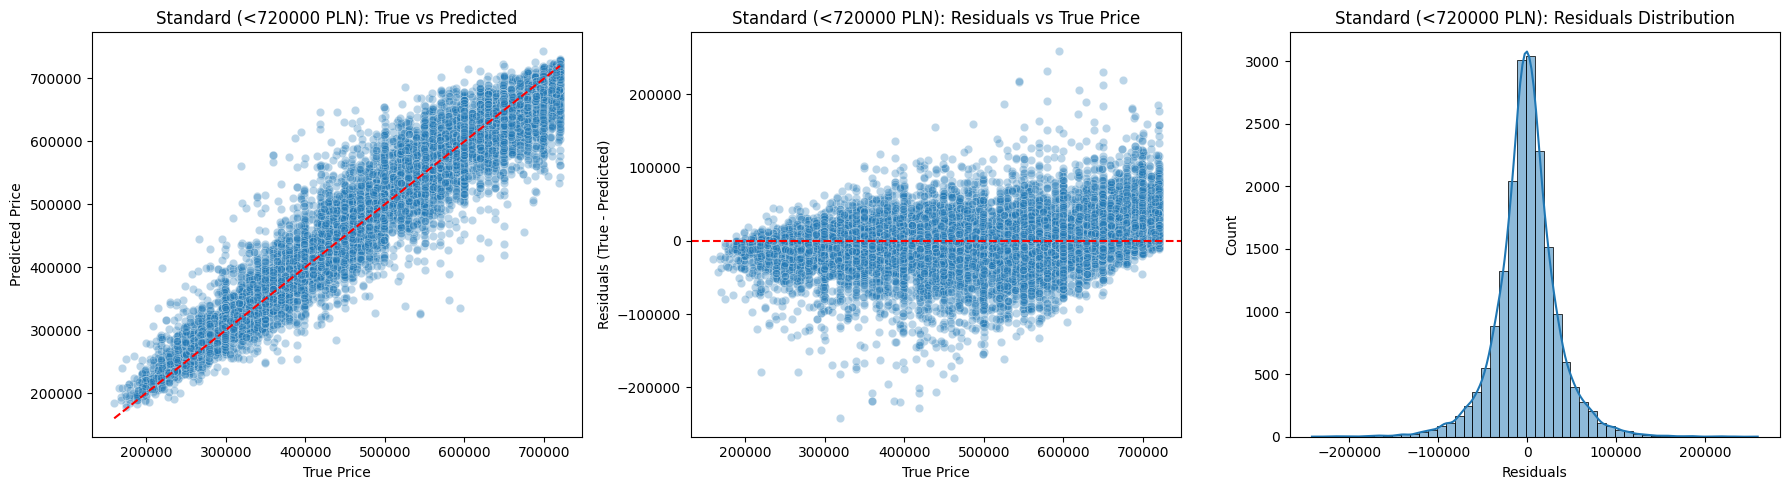

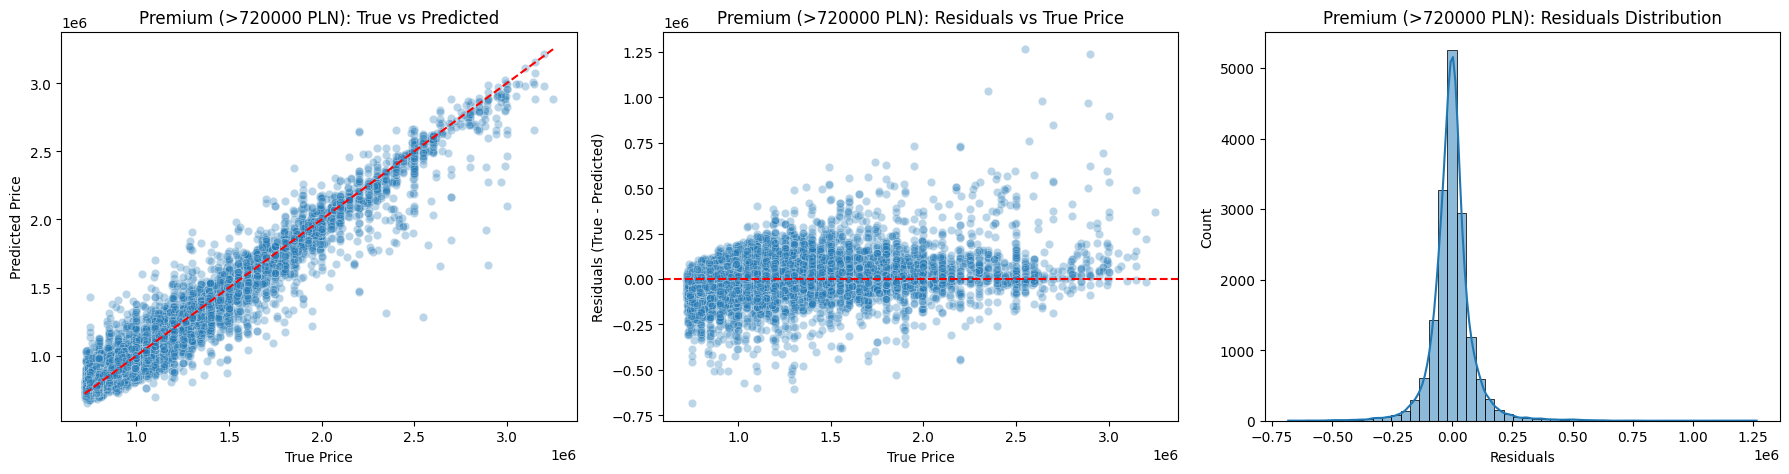

[0]	validation_0-rmse:126451.78550	validation_1-rmse:125536.03039
[1]	validation_0-rmse:116940.85191	validation_1-rmse:116121.67370
[2]	validation_0-rmse:108561.75847	validation_1-rmse:107842.77094
[3]	validation_0-rmse:101168.92550	validation_1-rmse:100544.09902
[4]	validation_0-rmse:94675.77101	validation_1-rmse:94166.25603
[5]	validation_0-rmse:88978.28827	validation_1-rmse:88541.80028
[6]	validation_0-rmse:83924.51038	validation_1-rmse:83617.27131
[7]	validation_0-rmse:79554.42802	validation_1-rmse:79324.38794
[8]	validation_0-rmse:75726.58611	validation_1-rmse:75628.15858
[9]	validation_0-rmse:72370.14935	validation_1-rmse:72386.50960
[10]	validation_0-rmse:69441.66544	validation_1-rmse:69606.45005
[11]	validation_0-rmse:66902.64650	validation_1-rmse:67211.05379
[12]	validation_0-rmse:64674.56393	validation_1-rmse:65122.97297
[13]	validation_0-rmse:62740.03379	validation_1-rmse:63336.36545
[14]	validation_0-rmse:61029.10486	validation_1-rmse:61773.94795
[15]	validation_0-rmse:5955

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'rmse'


In [95]:
def plot_results(y_true, y_pred, title):
    residuals = y_true - y_pred

    plt.figure(figsize=(18,5))

    # 1. Scatter plot: True vs Predicted
    plt.subplot(1,3,1)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.3)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{title}: True vs Predicted')

    # 2. Residuals plot: True vs Residuals
    plt.subplot(1,3,2)
    sns.scatterplot(x=y_true, y=residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('True Price')
    plt.ylabel('Residuals (True - Predicted)')
    plt.title(f'{title}: Residuals vs True Price')

    # 3. Residuals histogram (error distribution)
    plt.subplot(1,3,3)
    sns.histplot(residuals, bins=50, kde=True)
    plt.xlabel('Residuals')
    plt.title(f'{title}: Residuals Distribution')

    plt.tight_layout()
    plt.show()


# Call for both subsets:
plot_results(y_std_test, y_std_pred, f'Standard (<{threshold} PLN)')
plot_results(y_prm_test, y_prm_pred, f'Premium (>{threshold} PLN)')



eval_set_std = [(X_std_train, y_std_train), (X_std_test, y_std_test)]
eval_set_prm = [(X_prm_train, y_prm_train), (X_prm_test, y_prm_test)]

model_std.fit(
    X_std_train, y_std_train,
    eval_set=eval_set_std,
    #eval_metric="rmse",  # <-- fixed here
    #early_stopping_rounds=20,
    verbose=True
)

model_prm.fit(
    X_prm_train, y_prm_train,
    eval_set=eval_set_prm,
    #eval_metric="rmse",  # <-- fixed here
    #early_stopping_rounds=20,
    verbose=True
)


# After training, access evaluation results:
#results_std = model_std.evals_result()
#results_prm = model_prm.evals_result()

# def plot_training_curve(results, title):
#     epochs = len(results['validation_0']['rmse'])
#     x_axis = range(epochs)

#     plt.figure(figsize=(8,5))
#     plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
#     plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
#     plt.legend()
#     plt.xlabel('Epochs')
#     plt.ylabel('RMSE')
#     plt.title(f'{title} Training and Validation RMSE')
#     plt.show()

# plot_training_curve(results_std, 'Standard (<1M PLN)')
# plot_training_curve(results_prm, 'Premium (>1M PLN)')

**Using the split function chronologically(time-aware splitting) will allow the model to learn trends etc **

In [97]:

df['date'] = pd.to_datetime(df['date'])        # Ensure proper date format
df = df.sort_values('date')                    # Sort by time

# Threshold to separate Standard and Premium
threshold = 720000

# Define future cutoff (train before, predict after)
cutoff_date = '2024-05-01'
train_df = df[df['date'] < cutoff_date]
future_df = df[df['date'] >= cutoff_date]

# Features to drop from model input
drop_cols = ['price', 'price_bin', 'id', 'date', 'is_premium', 'log_price']

# Split by standard vs premium
def prepare_data(df_subset):
    standard = df_subset[df_subset['price'] <= threshold].copy()
    premium = df_subset[df_subset['price'] > threshold].copy()

    X_std = standard.drop(columns=drop_cols)
    y_std = standard['price']

    X_prm = premium.drop(columns=drop_cols)
    y_prm = premium['price']
    
    return X_std, y_std, X_prm, y_prm

X_std_train, y_std_train, X_prm_train, y_prm_train = prepare_data(train_df)
X_std_future, y_std_future, X_prm_future, y_prm_future = prepare_data(future_df)

# XGBoost hyperparameters
best_params = {
    'n_estimators': 500,
    'learning_rate': 0.1,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'random_state': 42,
    'enable_categorical': True,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

# Define and train models
model_std = xgb.XGBRegressor(**best_params)
model_prm = xgb.XGBRegressor(**best_params)

model_std.fit(X_std_train, y_std_train)
model_prm.fit(X_prm_train, y_prm_train)

# Predict future
y_std_future_pred = model_std.predict(X_std_future)
y_prm_future_pred = model_prm.predict(X_prm_future)

# Evaluation function
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name} Model Performance:")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")

# Report results
print_metrics(y_std_future, y_std_future_pred, f"Standard (>={cutoff_date})")
print_metrics(y_prm_future, y_prm_future_pred, f"Premium (>={cutoff_date})")



📊 Standard (>=2024-05-01) Model Performance:
MAE:  30,919.14
RMSE: 43,696.68
R²:   0.8896

📊 Premium (>=2024-05-01) Model Performance:
MAE:  76,715.45
RMSE: 129,305.61
R²:   0.9076


** Plotting Results **

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_84162/14363546.py:10: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/filiporlikowski/Documents/enProject/.venv-tf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


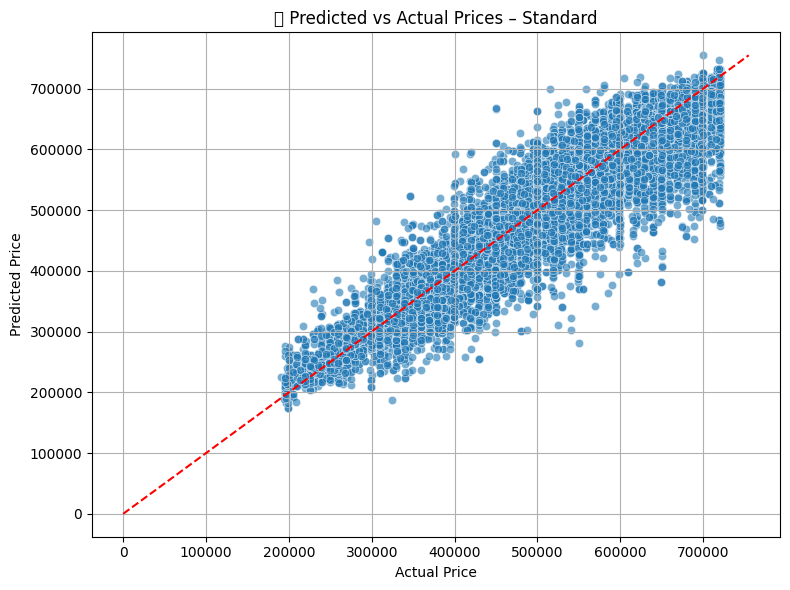

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_84162/14363546.py:10: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/filiporlikowski/Documents/enProject/.venv-tf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


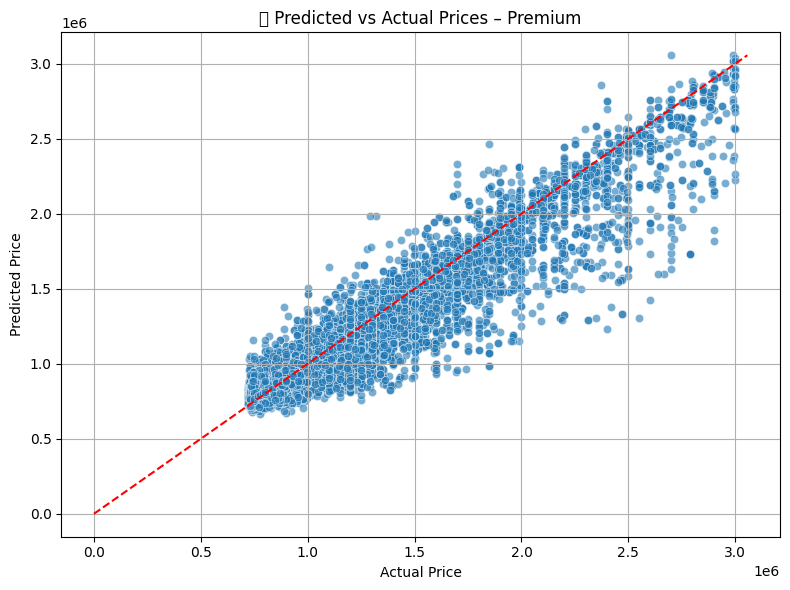

In [98]:
def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], '--r')  # Diagonal line
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"📌 Predicted vs Actual Prices – {title}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pred_vs_actual(y_std_future, y_std_future_pred, "Standard")
plot_pred_vs_actual(y_prm_future, y_prm_future_pred, "Premium")

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_84162/2250901153.py:17: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/filiporlikowski/Documents/enProject/.venv-tf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


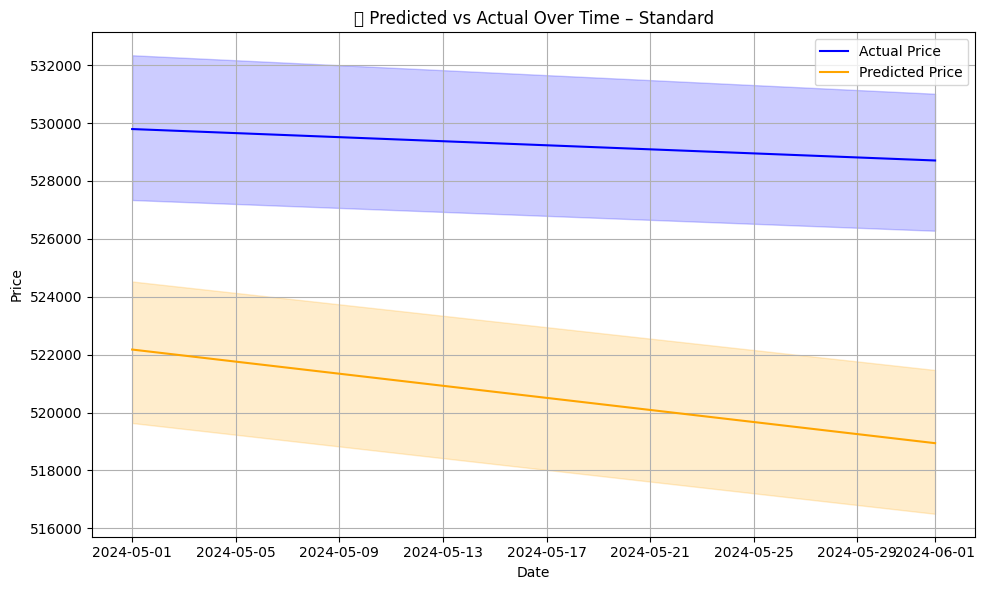

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_84162/2250901153.py:17: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/filiporlikowski/Documents/enProject/.venv-tf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


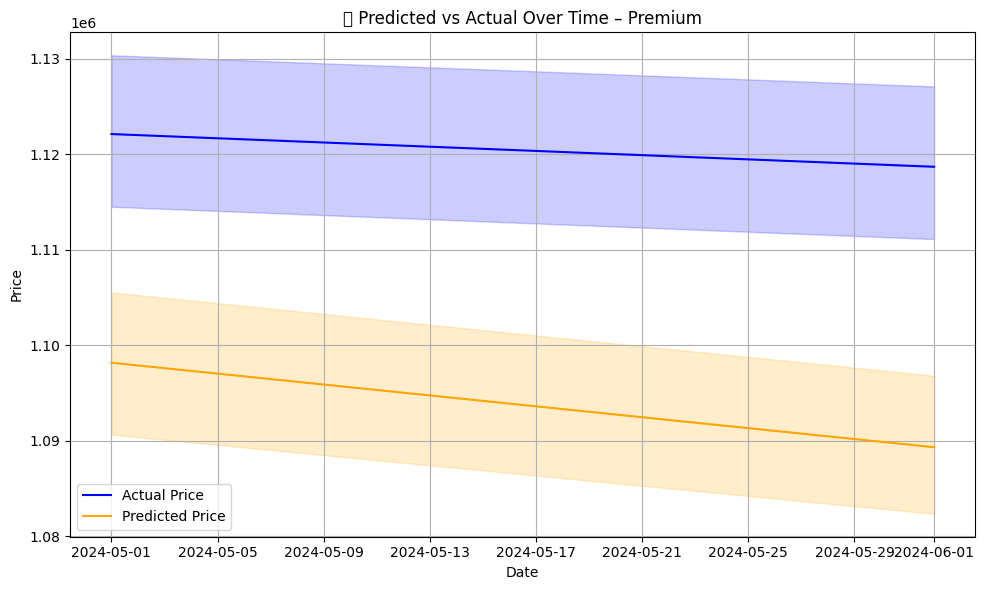

In [99]:
# Add predictions to future_df for plotting
future_df_std = future_df[future_df['price'] <= threshold].copy()
future_df_std['prediction'] = y_std_future_pred

future_df_prm = future_df[future_df['price'] > threshold].copy()
future_df_prm['prediction'] = y_prm_future_pred

def plot_time_series(df, title):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='date', y='price', label='Actual Price', color='blue')
    sns.lineplot(data=df, x='date', y='prediction', label='Predicted Price', color='orange')
    plt.title(f"📅 Predicted vs Actual Over Time – {title}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_time_series(future_df_std, "Standard")
plot_time_series(future_df_prm, "Premium")


/Users/filiporlikowski/Documents/enProject/.venv-tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


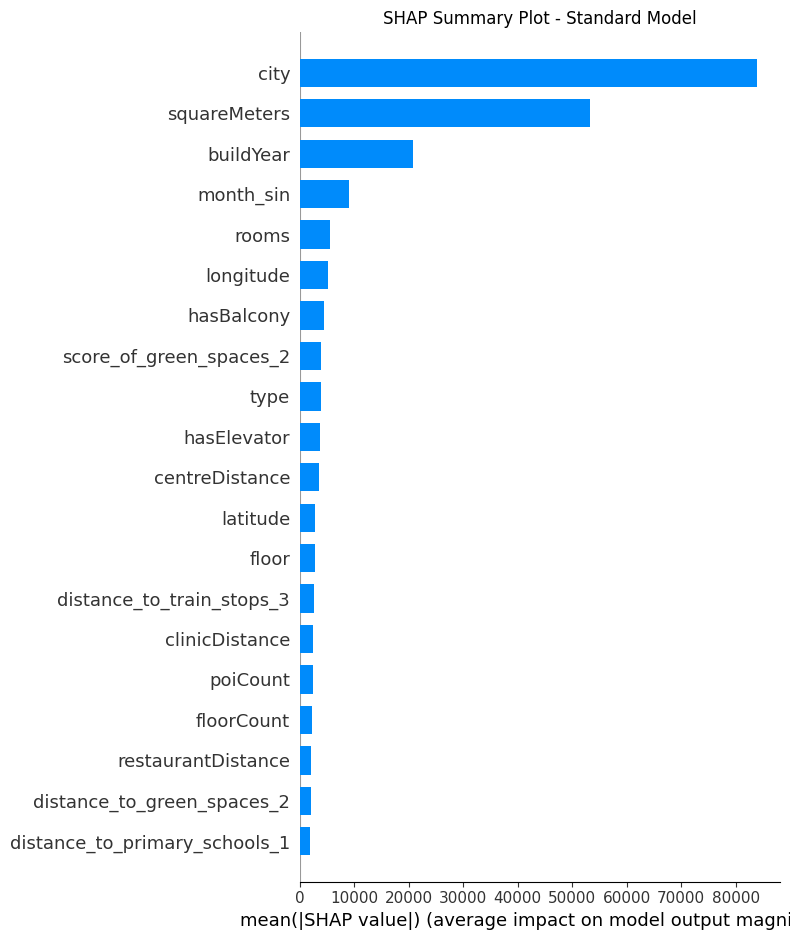

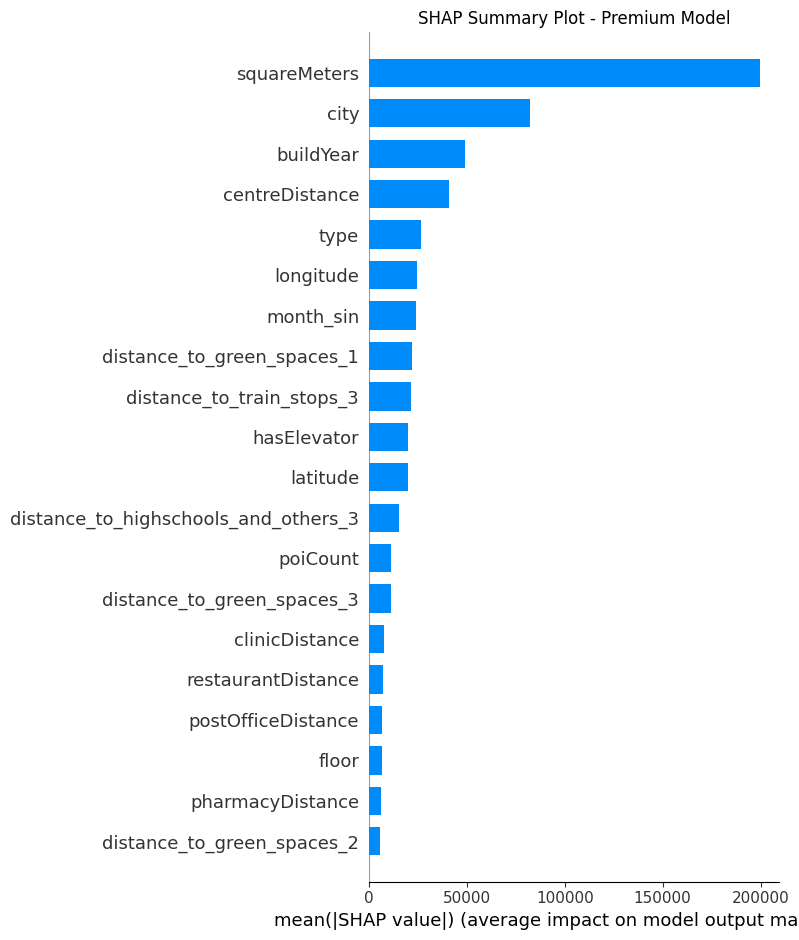

In [100]:
import shap

# Create SHAP explainer for each model
explainer_std = shap.Explainer(model_std)
explainer_prm = shap.Explainer(model_prm)

# Calculate SHAP values for training data (or test data)
shap_values_std = explainer_std(X_std_train)
shap_values_prm = explainer_prm(X_prm_train)

# Summary plot for Standard model
plt.title("SHAP Summary Plot - Standard Model")
shap.summary_plot(shap_values_std, X_std_train, plot_type="bar")

# Summary plot for Premium model
plt.title("SHAP Summary Plot - Premium Model")
shap.summary_plot(shap_values_prm, X_prm_train, plot_type="bar")


In [101]:
print(df)


                                     id city type  squareMeters  rooms  floor  \
57835  e991de0d4dff3152a37098dc56b86509    0    3         90.00    4.0    1.0   
64726  4ca9b861700b4598db9cc08ce74fa2ef   13    1         58.00    4.0    9.0   
64727  508d1c2b12c98b9ac81a1e21bba8b223   13    3         29.52    2.0    5.0   
64728  47b654db6ce234affc0e2df3c0b26176   13    3         46.98    2.0    5.0   
64729  4976c5c6b2b3b4f34d5e07d6ef041225   13    1         60.00    3.0    3.0   
...                                 ...  ...  ...           ...    ...    ...   
14336  501bc49fa4acd39968bf90b6c5a1690c   13    0        105.49    5.0    3.0   
14337  95e312e4bedfb7f5e63c425ffdbbd61d   13    2         61.00    3.0    6.0   
14338  da8b60611094d2f91c0a43007d28b392   13    1         37.60    2.0    8.0   
14340  1cfb1e06f8fe0245c9f5f2828c05596a   13    1         45.40    2.0    4.0   
0      811891f98a870dfd6e414374a0a85560   12    1         47.00    2.0    6.0   

       floorCount  buildYea

Rigth now I will apply logarithm to the price once again to balance the variance especially in premium prices seegment, and also plot feature importance once again. Check feature importance with:

xgb.plot_importance(model_std)
Then, iterate by:

Removing low-value features


📊 Standard (>=2024-05-01) Model Performance:
MAE:  31,366.69
RMSE: 44,507.94
R²:   0.8855

📊 Premium (>=2024-05-01) Model Performance:
MAE:  78,863.91
RMSE: 136,366.40
R²:   0.8972


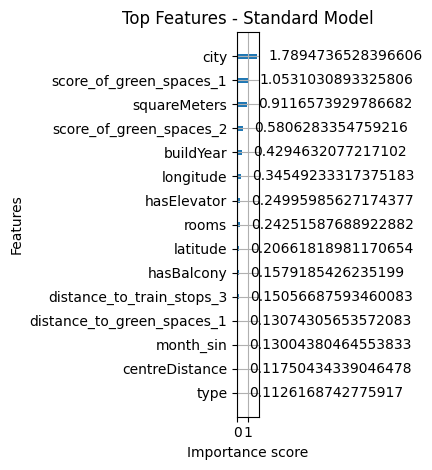

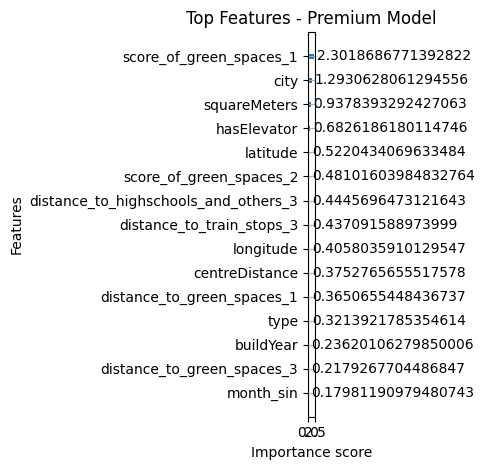

In [102]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Split price bins
threshold = 720000

# Date-based split
cutoff_date = '2024-05-01'
train_df = df[df['date'] < cutoff_date]
future_df = df[df['date'] >= cutoff_date]

# Columns to drop for model input
drop_cols = ['price', 'price_bin', 'id', 'date', 'is_premium', 'log_price']

# Modified prepare_data with log transform option
def prepare_data(df_subset, log_target=False):
    standard = df_subset[df_subset['price'] <= threshold].copy()
    premium = df_subset[df_subset['price'] > threshold].copy()

    X_std = standard.drop(columns=drop_cols)
    y_std = standard['price']
    X_prm = premium.drop(columns=drop_cols)
    y_prm = premium['price']

    if log_target:
        y_std = np.log1p(y_std)
        y_prm = np.log1p(y_prm)

    return X_std, y_std, X_prm, y_prm

# Prepare training and future sets
X_std_train, y_std_train, X_prm_train, y_prm_train = prepare_data(train_df, log_target=True)
X_std_future, y_std_future, X_prm_future, y_prm_future = prepare_data(future_df, log_target=False)

# XGBoost hyperparameters
best_params = {
    'n_estimators': 500,
    'learning_rate': 0.1,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 1.0,
    'random_state': 42,
    'enable_categorical': True,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

# Define and train models
model_std = xgb.XGBRegressor(**best_params)
model_prm = xgb.XGBRegressor(**best_params)

model_std.fit(X_std_train, y_std_train)
model_prm.fit(X_prm_train, y_prm_train)

# Predict and inverse log transform
y_std_future_pred = np.expm1(model_std.predict(X_std_future))
y_prm_future_pred = np.expm1(model_prm.predict(X_prm_future))

# Evaluation function
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name} Model Performance:")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")

# Evaluate future predictions
print_metrics(y_std_future, y_std_future_pred, f"Standard (>={cutoff_date})")
print_metrics(y_prm_future, y_prm_future_pred, f"Premium (>={cutoff_date})")

# Plot feature importance
def plot_importance(model, title):
    xgb.plot_importance(model, max_num_features=15, importance_type='gain', title=title)
    plt.tight_layout()
    plt.show()

plot_importance(model_std, "Top Features - Standard Model")
plot_importance(model_prm, "Top Features - Premium Model")

Why the difference between feature maps and results after log transformation: 

Difference Summary

Aspect	                First Code (log_target=True)	  Second Code (no log)
Target Transformation	Applies np.log1p(price) during training	Uses raw price
Prediction Output	    Applies np.expm1() to return to price scale	Outputs raw predicted price
Why it matters	         Stabilizes variance, reduces skew, helps model focus on relative differences	  Sensitive to outliers, may overfit extreme values
Usage Suitability	    Recommended for skewed price data, esp. Premium	Simpler, works fine if data is normally distributed
Training Example	    Model sees: log(700000) ≈ 13.46	  Model sees: 700000
Prediction Example	Model outputs 13.5 → converts to exp(13.5) ≈ 730000	Model directly outputs 730000



When you log-transform the target:


The loss function shifts from minimizing absolute price error to minimizing error in the log-price domain.
So, features that help predict relative price changes (e.g. “this house is 10% more expensive”) become more important.
Conversely, features that only help in explaining large absolute prices (like lot size in luxury homes) may lose influence in the log space.
🎯 Concrete Effects on Feature Importance

Feature	In raw price model	In log-transformed model
Features strongly associated with large absolute prices (e.g., size, area)	Higher importance	May drop slightly
Features that explain multiplicative changes (e.g., number of amenities, premium indicators)	Medium importance	Likely increase
Outlier-sensitive features (e.g., luxury indicators in a few homes)	High (due to bias)	Lower (log dampens impact)
Stable predictors across price tiers	Moderate	Higher in log model (more consistent behavior)
🧪 Example:

Let’s say:

In raw price model: size gets 40% importance, neighborhood_quality gets 5%
In log-transformed model: size drops to 25%, neighborhood_quality jumps to 15%
This tells you:

size explains big jumps in price, but less so the relative variance
neighborhood_quality helps explain why some homes are priced 20% higher — something better captured on a log scale
🧭 What Should You Do?

✅ Train both versions (log and raw)
✅ Compare their plot_importance() maps
🔍 Ask:
Are the top features stable across both?
Are there some features that only shine in the log model?
Are some features only helpful at extreme prices?